BackPropagation in RNNs(Continue)

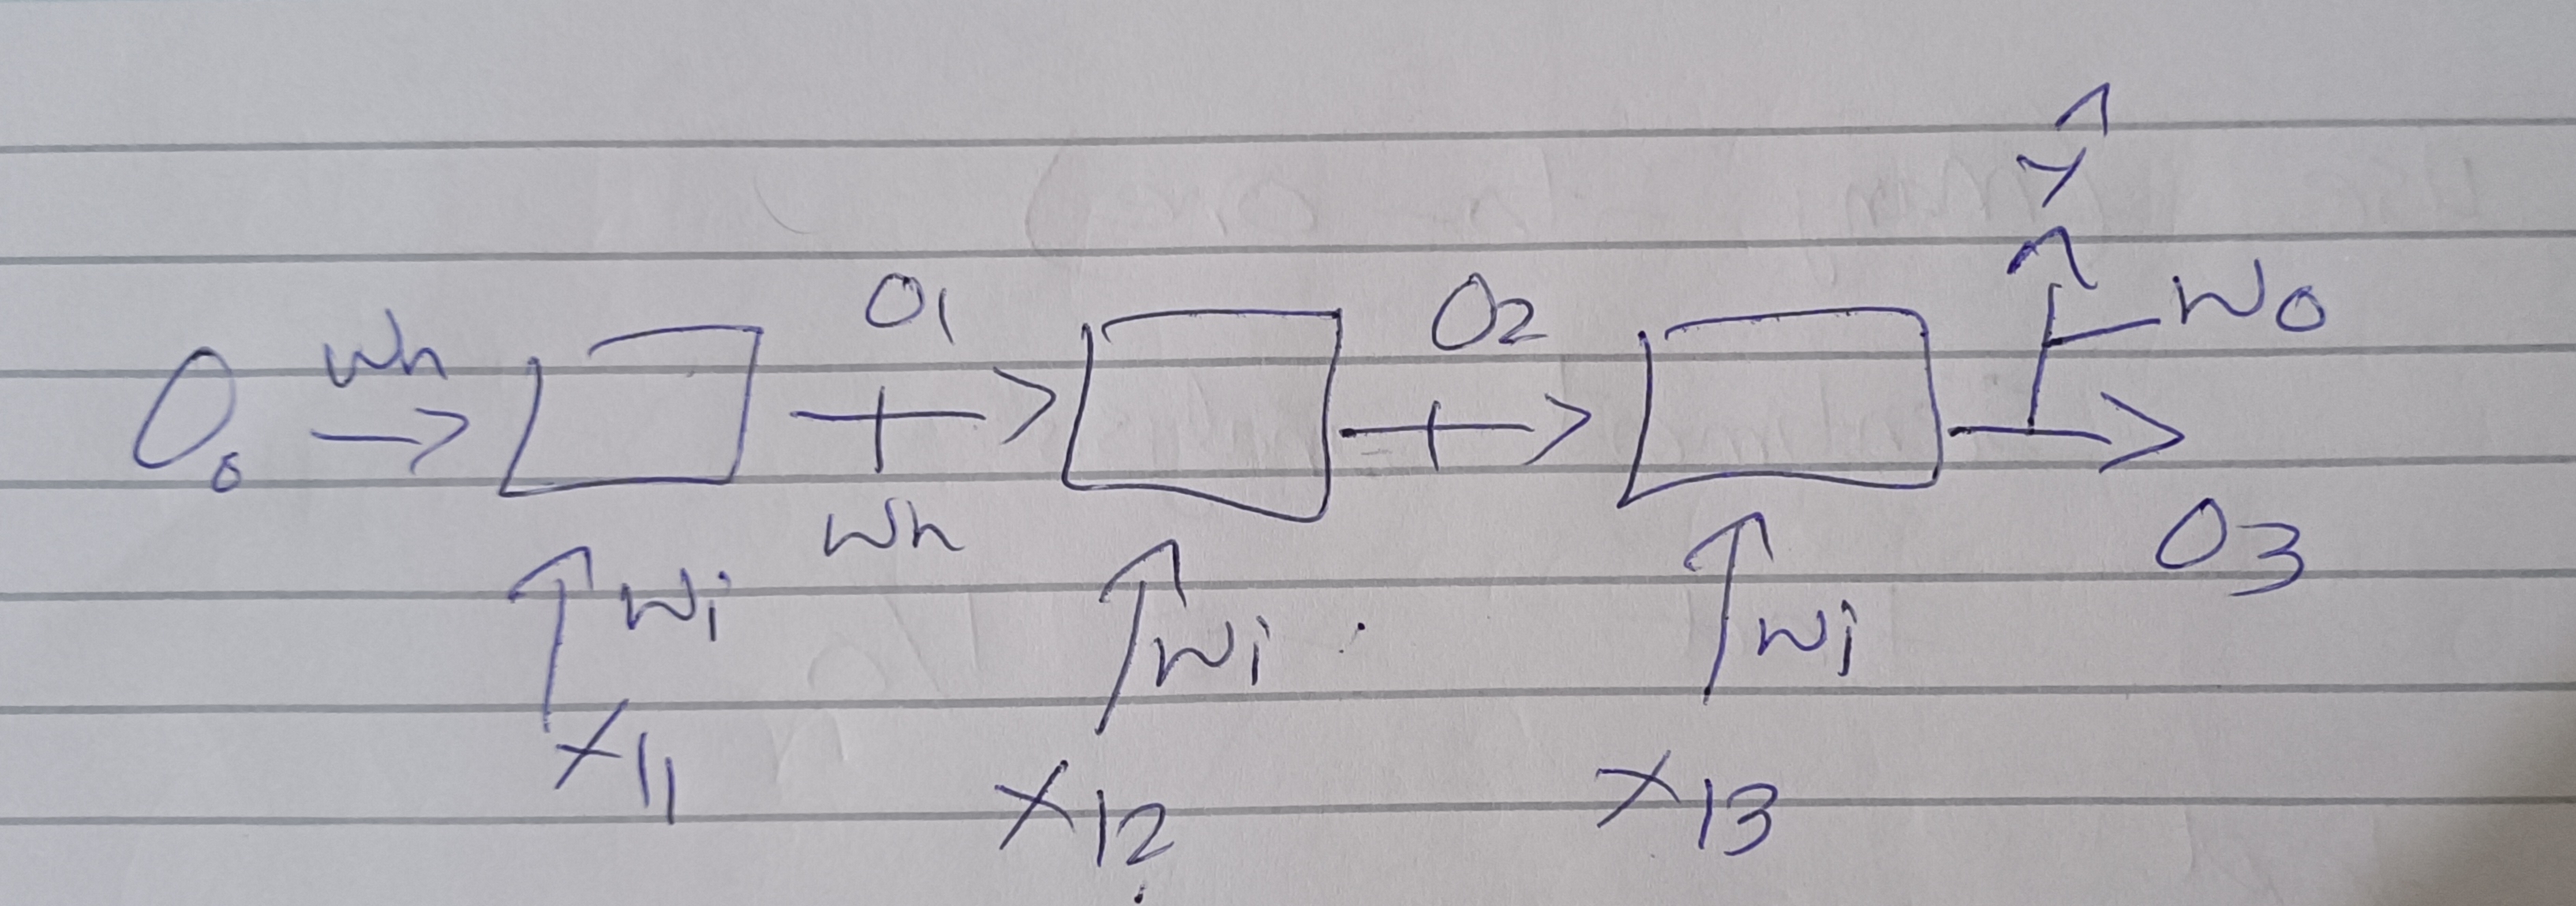

Code Example

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the IMDB dataset
# num_words=10000 means we only keep the top 10,000 most frequent words
max_features = 10000
maxlen = 100  # Cut texts after this number of words (to keep sequences same length)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# Pad sequences so that all inputs have the same length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Build RNN model
model = Sequential()
model.add(Embedding(max_features, 32))  # Convert word indices to embeddings
model.add(SimpleRNN(32))  # RNN layer with 32 units
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.3f}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (25000,)
Test data shape: (25000,)
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5394 - loss: 0.6867 - val_accuracy: 0.7002 - val_loss: 0.5667
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8086 - loss: 0.4315 - val_accuracy: 0.8102 - val_loss: 0.4319
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9289 - loss: 0.1934 - val_accuracy: 0.7806 - val_loss: 0.4986
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9779 - loss: 0.0809 - val_accuracy: 0.8044 - val_loss: 0.5565
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9924 - loss: 0.0326 - val_accuracy: 0.7600 - val_loss: 0.7062
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7635 - loss: 0.6974
Test Accuracy: 0.766


#Problem with RNNs

1. Longterm Dependency due to vanishing gradient

Example: The cat that was sitting on the mat near the window of the house that belongs to the old man **is** black.

2. Exploding Gradient Problem